In [ ]:
# ==================== 1. IMPORT LIBRARIES ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, auc
from keras.models import Sequential
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# After running the above cell and following the instructions to authorize Google Drive, you can load your data.
# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive.
# Example: Loading a CSV file from Google Drive
# df = pd.read_csv('/content/drive/MyDrive/your_folder/your_file.csv')
# print('Data loaded successfully!')
# display(df.head())

In [ ]:
# ==================== 2. LOAD DATA ====================
# Load các file từ dataset CARE
dataset = pd.read_csv('/content/drive/MyDrive/Research/CARE_To_Compare/Wind Farm A/datasets/0.csv', sep=';', low_memory=False, parse_dates=['time_stamp'])
event_info = pd.read_csv('/content/drive/MyDrive/Research/CARE_To_Compare/Wind Farm A/event_info.csv', sep=';', low_memory=False, parse_dates=['event_start', 'event_end'])
feature_desc = pd.read_csv('/content/drive/MyDrive/Research/CARE_To_Compare/Wind Farm A/feature_description.csv',sep=';', low_memory=False)

print(f"Dataset shape: {dataset.shape}")
print(f"Number of assets: {dataset['asset_id'].nunique()}")
print(f"Number of labeled events: {len(event_info)}")
dataset.head()

Dataset shape: (54986, 86)
Number of assets: 1
Number of labeled events: 22


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg
0,2022-08-04 06:10:00,0,0,train,0,22.0,302.9,129.4,1.7,1.7,...,-496.0,0.0,0.0,-1280.0,-496.0,0.0,0.0,0.0,0.0,26.0
1,2022-08-04 06:20:00,0,1,train,0,22.0,307.1,133.6,1.7,1.7,...,-490.0,0.0,0.0,-1278.0,-490.0,0.0,0.0,0.0,0.0,25.0
2,2022-08-04 06:30:00,0,2,train,0,22.0,340.6,167.1,0.9,0.9,...,-490.0,0.0,0.0,-1356.0,-490.0,0.0,0.0,0.0,0.0,25.0
3,2022-08-04 06:40:00,0,3,train,0,22.0,124.4,-49.1,1.5,1.5,...,-509.0,0.0,0.0,-1274.0,-509.0,0.0,0.0,0.0,0.0,26.0
4,2022-08-04 06:50:00,0,4,train,0,22.0,66.2,-107.3,1.0,1.0,...,-499.0,0.0,0.0,-1284.0,-499.0,0.0,0.0,0.0,0.0,26.0


In [ ]:
event_info.head()

,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,11,68,anomaly,2023-07-28 13:20:00,52063,2023-08-11 13:10:00,54076,Transformer failure
1,21,22,anomaly,2023-08-12 09:50:00,51888,2023-08-19 10:00:00,52892,Hydraulic group
2,21,72,anomaly,2023-10-10 08:40:00,52497,2023-10-17 08:40:00,53505,Gearbox failure
3,0,73,anomaly,2023-06-10 11:40:00,52745,2023-06-17 11:40:00,53753,Hydraulic group
4,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure


In [ ]:
feature_desc.head()

,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
1,sensor_1,average,Wind absolute direction,�,True,False
2,sensor_2,average,Wind relative direction,�,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False


In [ ]:
# ==================== 3. PREPROCESSING ====================
# Chọn một asset cụ thể để demo (ví dụ asset đầu tiên có event)
# Fix: Explicitly select asset_id = 0, as it's the only asset in the loaded dataset (0.csv)
asset_id = 0  # event_info['asset'].iloc[0] # Original line caused an empty data_asset as asset 11 is not in 0.csv
data_asset = dataset[dataset['asset_id'] == asset_id].copy()
data_asset = data_asset.sort_values('time_stamp').reset_index(drop=True)

# Chọn các feature số (loại bỏ counter, angle nếu cần theo feature_desc)
numeric_cols = [col for col in data_asset.columns if col not in
                ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_asset[numeric_cols])
data_scaled_df = pd.DataFrame(data_scaled, columns=numeric_cols, index=data_asset.index)

In [ ]:
# ==================== 4. XÁC ĐỊNH NORMAL DATA ĐỂ TRAIN ====================
# Chỉ train trên dữ liệu có status bình thường (theo paper: turbine-status-based labels)
normal_mask = data_asset['status_type_id'].isin([0, 1])  # Giả sử 0,1 là normal (kiểm tra thực tế)
train_data = data_scaled_df[normal_mask]

print(f"Training on {len(train_data)} normal samples")

Training on 47540 normal samples


In [ ]:
# ==================== 5. TRAIN ISOLATION FOREST ====================
iso_forest = IsolationForest(contamination=0.01, n_estimators=200, random_state=42)
iso_forest.fit(train_data)
iso_pred = iso_forest.predict(data_scaled_df)  # -1: anomaly, 1: normal
iso_anomalies = iso_pred == -1

In [ ]:
# ==================== 6. TRAIN LSTM AUTOENCODER ====================
sequence_length = 60  # 10 phút nếu data 10s/sample

def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return np.array(xs)

train_sequences = create_sequences(train_data.values, sequence_length)

# Build LSTM Autoencoder
model = Sequential([
    LSTM(64, input_shape=(sequence_length, train_data.shape[1]), return_sequences=True),
    LSTM(32),
    RepeatVector(sequence_length),
    LSTM(32, return_sequences=True),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(train_data.shape[1]))
])

model.compile(optimizer='adam', loss='mse')
model.fit(train_sequences, train_sequences, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Predict reconstruction error trên toàn bộ dữ liệu
full_sequences = create_sequences(data_scaled_df.values, sequence_length)
reconstructions = model.predict(full_sequences)
mse = np.mean(np.power(full_sequences - reconstructions, 2), axis=(1,2))

# Threshold: 95th percentile trên normal data
normal_mse = mse[:len(mse) - len(data_scaled_df) + len(train_data)]  # Ước lượng
threshold = np.percentile(mse[normal_mask[sequence_length:]], 95)
lstm_anomalies_seq = mse > threshold

# Map lại về timestamp gốc
lstm_anomalies = np.zeros(len(data_asset), dtype=bool)
for i, is_anom in enumerate(lstm_anomalies_seq):
    center_idx = i + sequence_length // 2
    lstm_anomalies[center_idx] = lstm_anomalies[center_idx] | is_anom

Epoch 1/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 204s 144ms/step - loss: 0.4300 - val_loss: 0.3523
Epoch 2/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 191s 143ms/step - loss: 0.2707 - val_loss: 0.3208
Epoch 3/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 202s 143ms/step - loss: 0.2445 - val_loss: 0.3039
Epoch 4/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 197s 147ms/step - loss: 0.2310 - val_loss: 0.2809
Epoch 5/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 186s 139ms/step - loss: 0.2209 - val_loss: 0.2656
Epoch 6/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 186s 139ms/step - loss: 0.2122 - val_loss: 0.2624
Epoch 7/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 188s 129ms/step - loss: 0.2056 - val_loss: 0.2585
Epoch 8/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 202s 129ms/step - loss: 0.1992 - val_loss: 0.2495
Epoch 9/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 218s 141ms/step - loss: 0.1951 - val_loss: 0.2448
Epoch 10/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 190s 142ms/step - loss: 0.1917 - val_loss: 0.2438
Epoch 11/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 201s 141ms/step - loss: 0.1887 - val

In [ ]:
# ==================== 9. SAVE RESULT ====================
# Tạo thư mục lưu kết quả
save_path = '/content/drive/MyDrive/Colab Results/Wind Turbine CARE'
#os.makedirs(save_path, exist_ok=True)
# Lưu model LSTM
model.save(f'{save_path}/lstm_autoencoder_asset0.h5')

In [ ]:
# ==================== 7. TÍNH CARE SCORE ====================
from datetime import timedelta

def calculate_care_score(y_true, y_pred, event_starts, event_ends, timestamps, max_earliness_days=30):
    """
    Tính CARE score theo paper
    y_true: binary, 1 nếu trong [event_start, event_end]
    y_pred: binary anomaly prediction
    """
    coverage = reliability = earliness = accuracy = 0
    n_events = len(event_starts)

    for start, end in zip(event_starts, event_ends):
        event_mask = (timestamps >= start) & (timestamps <= end)
        pre_event_mask = (timestamps >= start - timedelta(days=max_earliness_days)) & (timestamps < start)

        if event_mask.sum() == 0:
            continue

        # Coverage: có phát hiện ít nhất 1 anomaly trước hoặc trong event không?
        detected = np.any(y_pred[pre_event_mask | event_mask])
        coverage += 1 if detected else 0

        # Accuracy & Reliability: ít false positive trước event
        fp_before = np.sum(y_pred[pre_event_mask])
        reliability += 1 if fp_before == 0 else 0

        # Earliness: thời gian phát hiện đầu tiên trước event
        anomaly_times = timestamps[y_pred & (timestamps < start)]
        if len(anomaly_times) > 0:
            earliest = anomaly_times.max()
            earliness += (start - earliest).total_seconds() / (86400 * max_earliness_days)

    coverage /= n_events
    reliability /= n_events
    earliness /= n_events
    accuracy = 1 - (np.sum(y_pred & ~y_true) / len(y_pred))  # Simplified accuracy

    care_score = (coverage + accuracy + reliability + earliness) / 4
    return {
        'CARE': care_score,
        'Coverage': coverage,
        'Accuracy': accuracy,
        'Reliability': reliability,
        'Earliness': earliness
    }

# Tạo ground truth: điểm nào nằm trong khoảng event
y_true = np.zeros(len(data_asset), dtype=bool)
events_asset = event_info[event_info['asset'] == asset_id]
for _, row in events_asset.iterrows():
    mask = (data_asset['time_stamp'] >= row['event_start']) & (data_asset['time_stamp'] <= row['event_end'])
    y_true[mask] = True

timestamps = data_asset['time_stamp'].values

# Tính CARE cho 2 model
care_iso = calculate_care_score(y_true, iso_anomalies,
            events_asset['event_start'], events_asset['event_end'], timestamps)
care_lstm = calculate_care_score(y_true, lstm_anomalies,
            events_asset['event_start'], events_asset['event_end'], timestamps)

print("=== CARE SCORE COMPARISON ===")
print(f"Isolation Forest: {care_iso}")
print(f"LSTM Autoencoder: {care_lstm}")

=== CARE SCORE COMPARISON ===
Isolation Forest: {'CARE': np.float64(0.4860692077680379), 'Coverage': 0.8, 'Accuracy': np.float64(0.986360164405485), 'Reliability': 0.0, 'Earliness': 0.15791666666666665}
LSTM Autoencoder: {'CARE': np.float64(0.46590335031408664), 'Coverage': 0.8, 'Accuracy': np.float64(0.9481504382933837), 'Reliability': 0.0, 'Earliness': 0.11546296296296296}


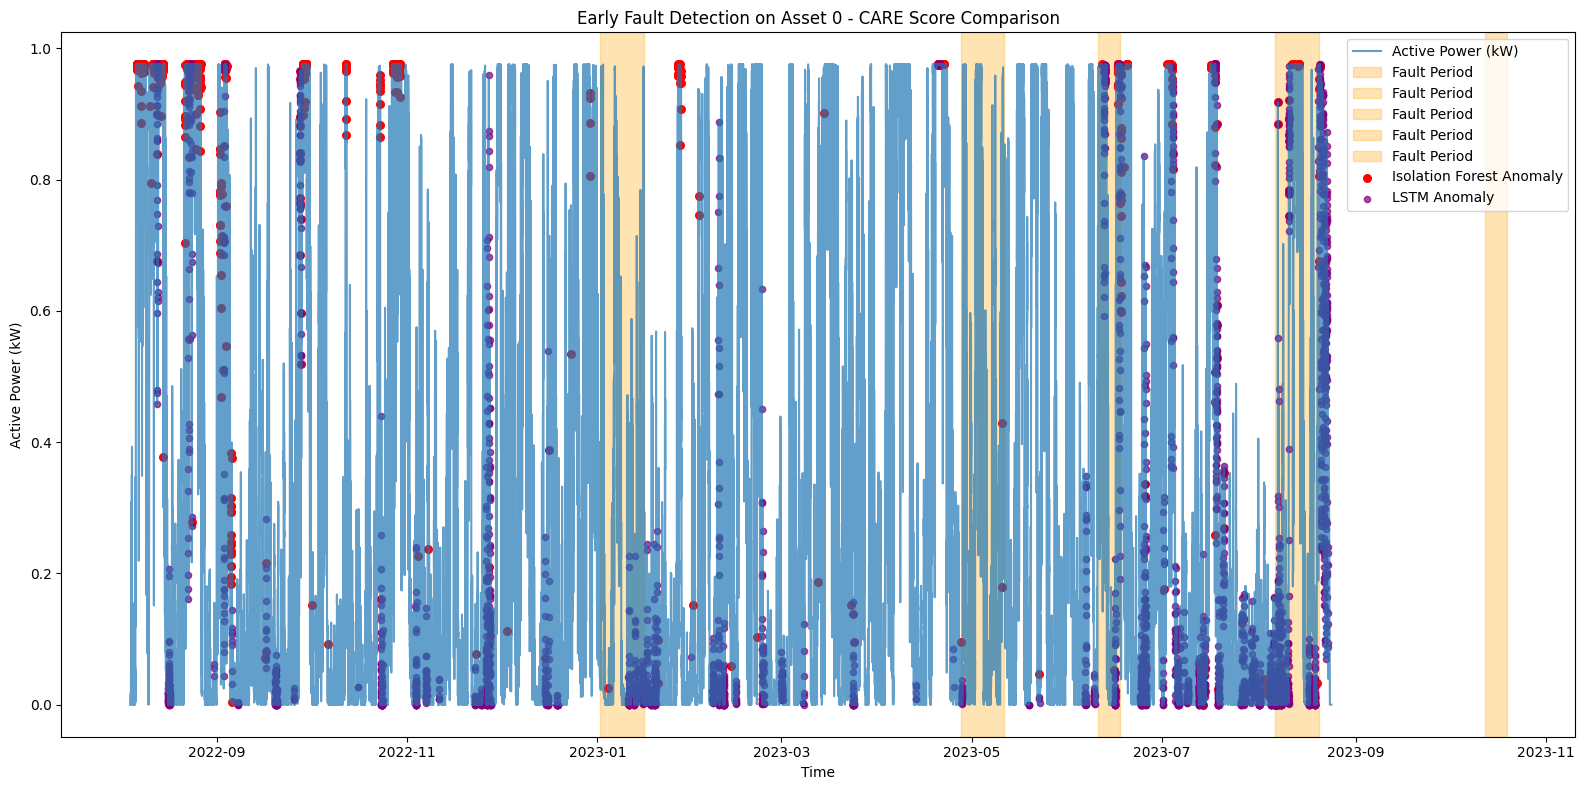

In [ ]:
# ==================== 8. VISUALIZATION ====================
plt.figure(figsize=(16, 8))
plt.plot(data_asset['time_stamp'], data_asset['power_29_avg'], label='Active Power (kW)', alpha=0.7)

# Vẽ event periods
for _, row in events_asset.iterrows():
    plt.axvspan(row['event_start'], row['event_end'], color='orange', alpha=0.3, label='Fault Period')

anomaly_times_iso = data_asset['time_stamp'][iso_anomalies]
anomaly_times_lstm = data_asset['time_stamp'][lstm_anomalies]

plt.scatter(anomaly_times_iso, data_asset['power_29_avg'][iso_anomalies],
            color='red', label='Isolation Forest Anomaly', s=30)
plt.scatter(anomaly_times_lstm, data_asset['power_29_avg'][lstm_anomalies],
            color='purple', label='LSTM Anomaly', s=20, alpha=0.7)

plt.title(f'Early Fault Detection on Asset {asset_id} - CARE Score Comparison')
plt.xlabel('Time')
plt.ylabel('Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

# Lưu anomalies
pd.DataFrame({'timestamp': timestamps, 'iso_anomaly': iso_anomalies, 'lstm_anomaly': lstm_anomalies}).to_csv(f'{save_path}/anomalies_asset0.csv', index=False)
# Lưu biểu đồ
plt.savefig(f'{save_path}/anomaly_plot_asset0.png')

# Lưu CARE score
with open(f'{save_path}/care_score.txt', 'w') as f:
    f.write(f"Isolation Forest: {care_iso}\nLSTM: {care_lstm}")

<Figure size 640x480 with 0 Axes>